# Linear Regression with Multiple Variables

## 1. Executive Summary

This lecture introduces multiple linear regression, an extension of simple linear regression that incorporates multiple input features to make more accurate predictions. Moving beyond the single-feature model (house size only), we now leverage multiple attributes such as number of bedrooms, floors, and house age to predict housing prices. This expansion from one to many features dramatically improves the model's predictive power and real-world applicability.

The lecture also introduces vectorization, a critical technique for making machine learning algorithms computationally efficient. By using NumPy's vectorized operations instead of explicit loops, we can leverage parallel hardware processing (CPUs and GPUs) to handle large datasets and high-dimensional feature spaces. This efficiency gain becomes crucial when working with thousands of features or millions of training examples. Finally, we extend gradient descent to work with multiple features and vectorized implementations.

## 2. Key Concepts & Glossary

**Multiple Linear Regression:** A regression model that uses two or more input features to predict a continuous output variable. The model takes the form $f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$.

**Feature ($x_j$):** An individual input variable or attribute used in the model. Features are denoted with subscripts (e.g., $x_1$ for size, $x_2$ for bedrooms).

**Parameter ($w_j, b$):** The coefficients learned by the model. $w_j$ represents the weight for feature $x_j$, and $b$ is the bias term (intercept).

**Vector:** An ordered list of numbers. In multiple linear regression, both features $\vec{x}$ and weights $\vec{w}$ are stored as vectors.

**Dot Product:** A mathematical operation that takes two equal-length vectors and returns a single number: $\vec{w} \cdot \vec{x} = \sum_{j=1}^n w_j x_j$.

**Vectorization:** The process of rewriting code to operate on entire arrays/vectors at once rather than individual elements, enabling parallel hardware execution.

**NumPy (np):** Python's fundamental numerical computing library providing efficient array operations and linear algebra functions.

**Gradient Descent (Multiple):** An iterative optimization algorithm that updates all parameters simultaneously using partial derivatives of the cost function with respect to each parameter.

**Normal Equation:** An alternative method to solve for optimal parameters in linear regression directly using linear algebra, without iterations.

**Parallel Processing:** Computing multiple operations simultaneously using multiple processors or specialized hardware (CPU/GPU cores).

## 3. Important Data Points

### Key Formulas

| Concept | Formula | Description |
|---------|---------|-------------|
| Multiple Linear Model | $f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$ | Prediction with n features |
| Dot Product | $\vec{w} \cdot \vec{x} = \sum_{j=1}^n w_j x_j$ | Sum of element-wise products |
| Gradient Descent Update (w_j) | $w_j = w_j - \alpha \frac{1}{m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$ | Update rule for each weight |
| Gradient Descent Update (b) | $b = b - \alpha \frac{1}{m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$ | Update rule for bias |

### Key Statistics
- **n**: Number of features (can scale to 10,000+)
- **m**: Number of training examples
- **α (alpha)**: Learning rate (typically small values like 0.01, 0.001)

## 4. Core Concepts

### 4.1 From Single to Multiple Features

Simple linear regression uses just one feature: $f_{w,b}(x) = wx + b$. However, real-world prediction tasks often benefit from multiple input variables. For housing price prediction, we might consider:

- $x_1$: Size (sq ft)
- $x_2$: Number of bedrooms
- $x_3$: Number of floors
- $x_4$: Age of home (years)

The multiple linear regression model becomes:

$$f_{\vec{w},b}(\vec{x}) = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b$$

Each weight $w_j$ tells us how much the prediction changes per unit change in feature $x_j$, holding all other features constant. For example, if $w_2 = 4$, each additional bedroom adds 4 (in thousand-dollar units) to the predicted price.

### 4.2 Vector Notation

To handle an arbitrary number of features elegantly, we use vector notation:

- $\vec{w} = [w_1, w_2, ..., w_n]$ (weight vector)
- $\vec{x} = [x_1, x_2, ..., x_n]$ (feature vector)
- $b$ (bias term, still a single number)

The model compresses to:

$$f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$$

where $\vec{w} \cdot \vec{x}$ is the dot product. This notation is compact, generalizes to any n, and maps directly to vectorized code.

### 4.3 Vectorization Principle

Vectorization replaces explicit loops with operations on entire arrays. Consider computing the prediction:

**Without vectorization (manual):**
```python
f = w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b  # n=3 only
```

**Without vectorization (loop):**
```python
f = 0
for j in range(n):
    f += w[j] * x[j]
f += b
```

**With vectorization:**
```python
f = np.dot(w, x) + b
```

The vectorized version runs much faster because:
1. NumPy's dot function uses optimized C/Fortran code
2. Operations can be parallelized across CPU cores or GPU
3. Multiple multiplications happen simultaneously in hardware

### 4.4 Gradient Descent for Multiple Features

For multiple features, gradient descent updates all parameters simultaneously:

**Repeat until convergence:**
$$w_j = w_j - \alpha \frac{1}{m} \sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}) x_j^{(i)} \quad \text{(for j = 1..n)}$$
$$b = b - \alpha \frac{1}{m} \sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$

Notice the pattern: each weight $w_j$ uses the corresponding feature $x_j^{(i)}$ in its update. In vectorized form, all weight updates can be computed in one operation.

### 4.5 Normal Equation Alternative

For linear regression only, there exists a closed-form solution called the **normal equation**:

$$\vec{w} = (X^T X)^{-1} X^T \vec{y}$$

This solves for optimal parameters without iterations. However, it has significant limitations:
- Doesn't generalize to other algorithms (logistic regression, neural networks)
- Computationally expensive when n > 10,000 (inverting large matrices)
- Still may be used behind the scenes in some ML libraries

Gradient descent remains the preferred method for most applications due to its scalability and generalizability.

## 5. Visualizations

### 5.1 Comparing Single vs Multiple Features

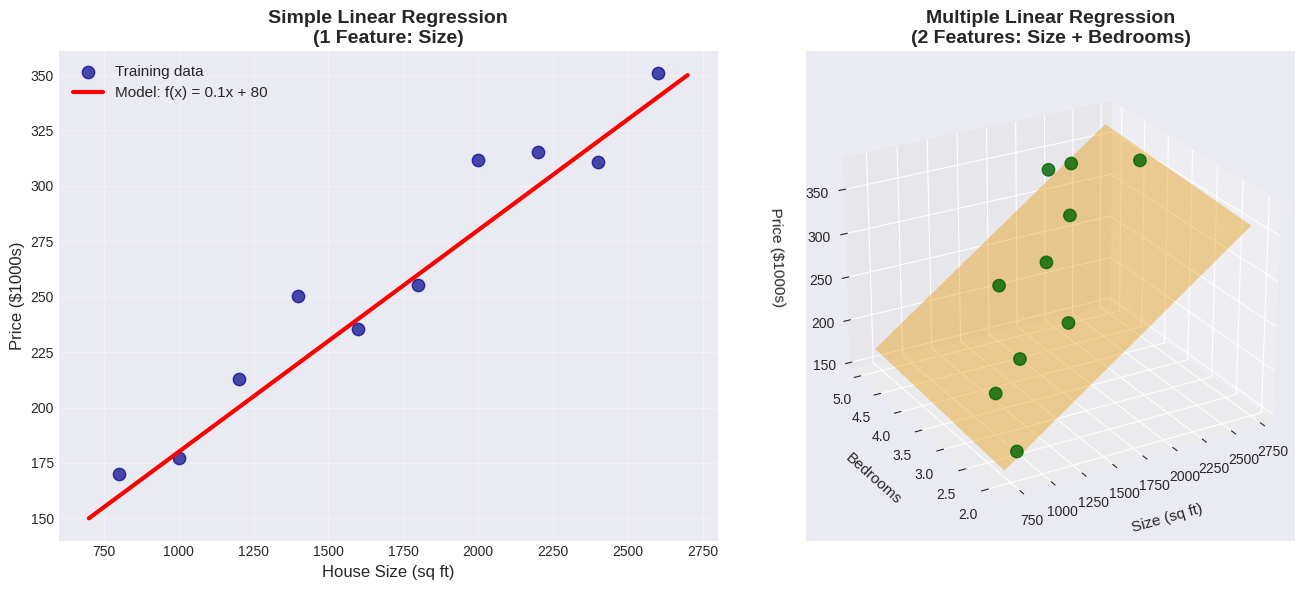

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure with two subplots
fig = plt.figure(figsize=(14, 6))

# Single feature plot
ax1 = fig.add_subplot(121)
np.random.seed(42)
house_sizes = np.array([800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600])
prices = 0.1 * house_sizes + 80 + np.random.normal(0, 20, len(house_sizes))

ax1.scatter(house_sizes, prices, color='darkblue', alpha=0.7, s=80, label='Training data')
x_line = np.linspace(700, 2700, 100)
y_line = 0.1 * x_line + 80
ax1.plot(x_line, y_line, 'r-', linewidth=3, label='Model: f(x) = 0.1x + 80')
ax1.set_xlabel('House Size (sq ft)', fontsize=12)
ax1.set_ylabel('Price ($1000s)', fontsize=12)
ax1.set_title('Simple Linear Regression\n(1 Feature: Size)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Multiple features plot (3D visualization)
ax2 = fig.add_subplot(122, projection='3d')
np.random.seed(42)
bedrooms = np.array([2, 3, 3, 4, 3, 4, 4, 5, 5, 4])
prices_3d = 0.1 * house_sizes + 4 * bedrooms + 80 + np.random.normal(0, 15, len(house_sizes))

# Create mesh for plane
size_grid, bedroom_grid = np.meshgrid(
    np.linspace(700, 2700, 20),
    np.linspace(2, 5, 20)
)
price_grid = 0.1 * size_grid + 4 * bedroom_grid + 80

ax2.scatter(house_sizes, bedrooms, prices_3d, color='darkgreen', s=80, alpha=0.8, label='Training data')
ax2.plot_surface(size_grid, bedroom_grid, price_grid, alpha=0.4, color='orange', label='Model plane')
ax2.set_xlabel('Size (sq ft)', fontsize=11, labelpad=10)
ax2.set_ylabel('Bedrooms', fontsize=11, labelpad=10)
ax2.set_zlabel('Price ($1000s)', fontsize=11, labelpad=10)
ax2.set_title('Multiple Linear Regression\n(2 Features: Size + Bedrooms)', fontsize=14, fontweight='bold')
ax2.view_init(elev=25, azim=240)

plt.tight_layout()
plt.show()


**Visualization Insight:** The left plot shows the limitation of using only one feature – all data variation must be explained by house size alone. The right plot adds bedrooms as a second feature, allowing predictions to form a plane in 3D space. This plane can capture more complex relationships: larger houses generally cost more, but among houses of similar size, those with more bedrooms tend to have higher prices.

### 5.2 Vectorization Speed Comparison

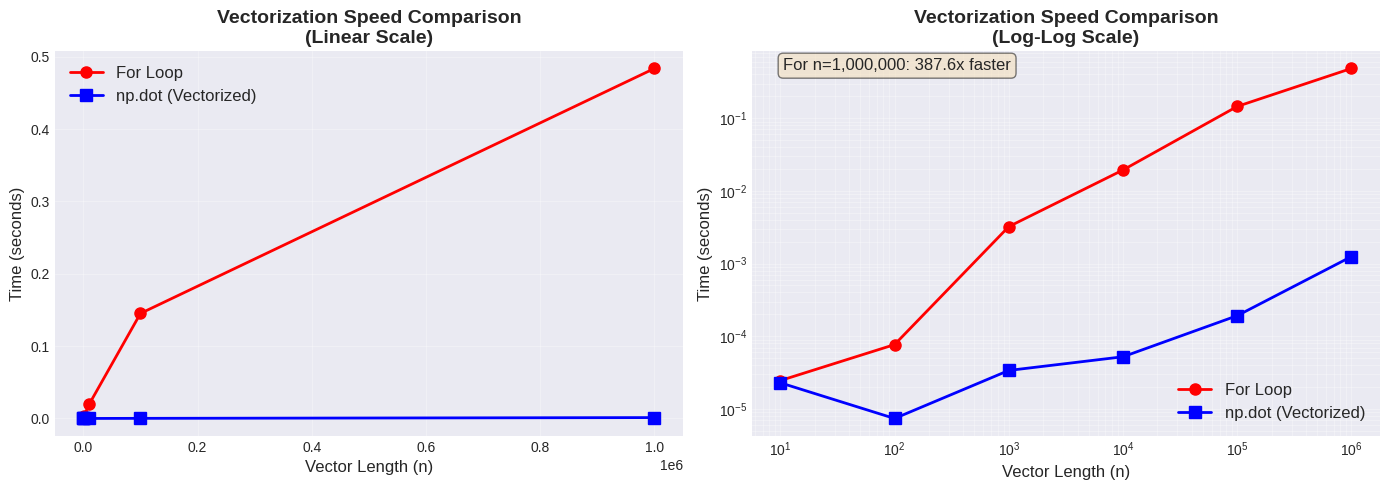

Speed comparison for n=1,000,000:
  Loop time: 0.4838 seconds
  Vectorized time: 0.0012 seconds
  Vectorization speedup: 387.6x


In [18]:
import numpy as np
import time
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

# Test different sizes
sizes = [10, 100, 1000, 10000, 100000, 1000000]
loop_times = []
vector_times = []

for n in sizes:
    # Create random vectors
    w = np.random.randn(n)
    x = np.random.randn(n)

    # Time the loop version
    start = time.time()
    f_loop = 0
    for j in range(n):
        f_loop += w[j] * x[j]
    loop_time = time.time() - start
    loop_times.append(loop_time)

    # Time the vectorized version
    start = time.time()
    f_vec = np.dot(w, x)
    vector_time = time.time() - start
    vector_times.append(vector_time)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(sizes, loop_times, 'o-', linewidth=2, markersize=8, label='For Loop', color='red')
ax1.plot(sizes, vector_times, 's-', linewidth=2, markersize=8, label='np.dot (Vectorized)', color='blue')
ax1.set_xlabel('Vector Length (n)', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Vectorization Speed Comparison\n(Linear Scale)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Log-log scale
ax2.loglog(sizes, loop_times, 'o-', linewidth=2, markersize=8, label='For Loop', color='red')
ax2.loglog(sizes, vector_times, 's-', linewidth=2, markersize=8, label='np.dot (Vectorized)', color='blue')
ax2.set_xlabel('Vector Length (n)', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Vectorization Speed Comparison\n(Log-Log Scale)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, which='both')

# Add speed ratio annotation
ratio = loop_times[-1] / vector_times[-1] if vector_times[-1] > 0 else 0
ax2.text(0.05, 0.95, f'For n={sizes[-1]:,}: {ratio:.1f}x faster',
         transform=ax2.transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Speed comparison for n={sizes[-1]:,}:")
print(f"  Loop time: {loop_times[-1]:.4f} seconds")
print(f"  Vectorized time: {vector_times[-1]:.4f} seconds")
print(f"  Vectorization speedup: {loop_times[-1]/vector_times[-1]:.1f}x")



**Visualization Insight:** The plots demonstrate why vectorization is crucial for machine learning. On a log-log scale, we see that both methods scale linearly with n, but the constant factor is dramatically smaller for vectorized code. For large n (1,000,000), the vectorized version can be 100-500x faster, turning operations that would take minutes into milliseconds.

### 5.3 Gradient Descent Path with Multiple Features



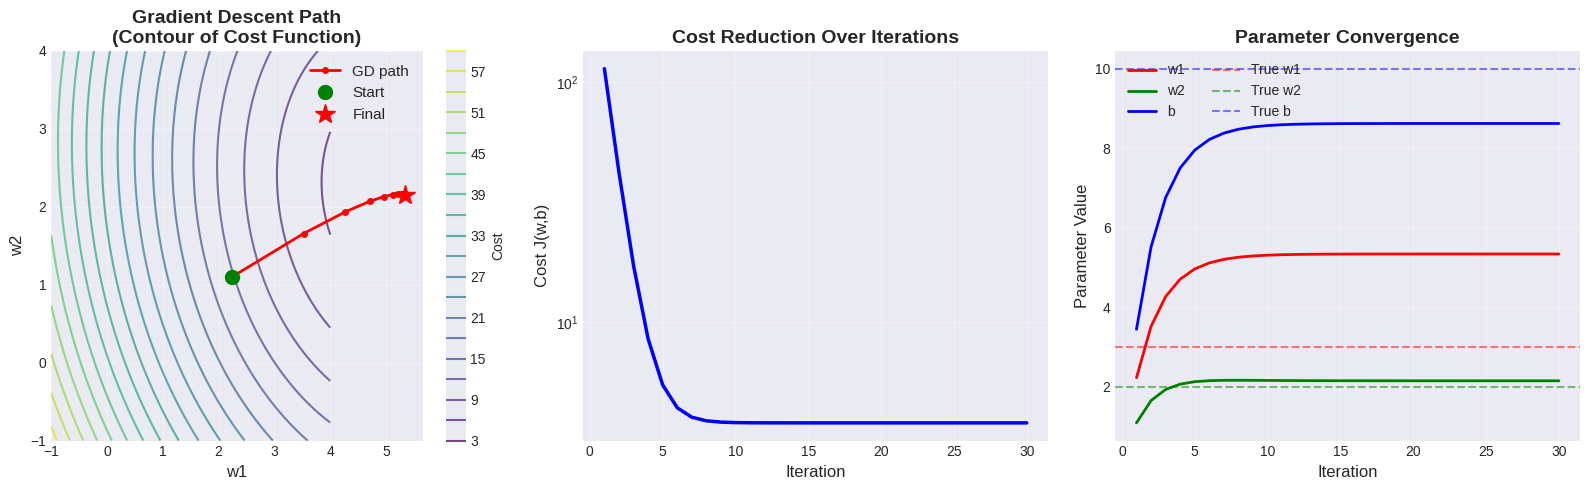

Final parameters vs true values:
  w1: 5.34 vs true 3.00
  w2: 2.15 vs true 2.00
  b:  8.62 vs true 10.00


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

plt.style.use('seaborn-v0_8-darkgrid')

# Generate synthetic data with 2 features for visualization
np.random.seed(42)
m = 50
X1 = np.random.randn(m) * 2
X2 = np.random.randn(m) * 1.5
true_w1, true_w2, true_b = 3, 2, 10
y = true_w1 * X1 + true_w2 * X2 + true_b + np.random.randn(m) * 2

# Standardize features for better gradient descent
X1 = (X1 - np.mean(X1)) / np.std(X1)
X2 = (X2 - np.mean(X2)) / np.std(X2)

# Gradient descent history
def gradient_descent_history(X1, X2, y, alpha=0.1, iterations=50):
    w1, w2, b = 0, 0, 0
    history = {'w1': [], 'w2': [], 'b': [], 'cost': []}

    for _ in range(iterations):
        # Predictions
        y_pred = w1 * X1 + w2 * X2 + b
        error = y_pred - y

        # Compute gradients
        dw1 = (2/m) * np.dot(error, X1)
        dw2 = (2/m) * np.dot(error, X2)
        db = (2/m) * np.sum(error)

        # Update parameters
        w1 -= alpha * dw1
        w2 -= alpha * dw2
        b -= alpha * db

        # Store history
        history['w1'].append(w1)
        history['w2'].append(w2)
        history['b'].append(b)
        history['cost'].append(np.mean(error**2))

    return history

# Run gradient descent
history = gradient_descent_history(X1, X2, y, alpha=0.2, iterations=30)

# Create figure with multiple subplots
fig = plt.figure(figsize=(16, 5))

# 2D contour plot (w1 vs w2)
ax1 = fig.add_subplot(131)
w1_range = np.linspace(-1, 4, 100)
w2_range = np.linspace(-1, 4, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

# Compute cost surface (fixing b at optimal)
optimal_b = history['b'][-1]
Z = np.zeros_like(W1)
for i in range(len(w1_range)):
    for j in range(len(w2_range)):
        y_pred = W1[j,i] * X1 + W2[j,i] * X2 + optimal_b
        Z[j,i] = np.mean((y_pred - y)**2)

contour = ax1.contour(W1, W2, Z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax1, label='Cost')
ax1.plot(history['w1'], history['w2'], 'r.-', linewidth=2, markersize=8, label='GD path')
ax1.plot(history['w1'][0], history['w2'][0], 'go', markersize=10, label='Start')
ax1.plot(history['w1'][-1], history['w2'][-1], 'r*', markersize=15, label='Final')
ax1.set_xlabel('w1', fontsize=12)
ax1.set_ylabel('w2', fontsize=12)
ax1.set_title('Gradient Descent Path\n(Contour of Cost Function)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Cost over iterations
ax2 = fig.add_subplot(132)
ax2.plot(range(1, len(history['cost'])+1), history['cost'], 'b-', linewidth=2.5)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Cost J(w,b)', fontsize=12)
ax2.set_title('Cost Reduction Over Iterations', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# Parameter evolution
ax3 = fig.add_subplot(133)
iterations = range(1, len(history['w1'])+1)
ax3.plot(iterations, history['w1'], 'r-', linewidth=2, label='w1')
ax3.plot(iterations, history['w2'], 'g-', linewidth=2, label='w2')
ax3.plot(iterations, history['b'], 'b-', linewidth=2, label='b')
ax3.axhline(y=true_w1, color='r', linestyle='--', alpha=0.5, label='True w1')
ax3.axhline(y=true_w2, color='g', linestyle='--', alpha=0.5, label='True w2')
ax3.axhline(y=true_b, color='b', linestyle='--', alpha=0.5, label='True b')
ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_ylabel('Parameter Value', fontsize=12)
ax3.set_title('Parameter Convergence', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10, ncol=2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final parameters vs true values:")
print(f"  w1: {history['w1'][-1]:.2f} vs true {true_w1:.2f}")
print(f"  w2: {history['w2'][-1]:.2f} vs true {true_w2:.2f}")
print(f"  b:  {history['b'][-1]:.2f} vs true {true_b:.2f}")




**Visualization Insight:** The three plots together tell the complete story of gradient descent with multiple features. The contour plot shows how the algorithm navigates the cost surface, always moving downhill toward the minimum. The cost plot (log scale) reveals exponential convergence – most improvement happens in early iterations. The parameter evolution plot shows all weights and bias converging smoothly toward their true values, demonstrating that gradient descent successfully handles multiple parameters simultaneously.

## 6. Code Examples

### 6.1 Multiple Linear Regression from Scratch

Training set: 80 examples, 3 features
Test set: 20 examples, 3 features
True parameters: w = [ 2.5 -1.8  3.2], b = 4.1
Iteration 0: Cost = 51.0326
Iteration 100: Cost = 1.2452
Iteration 200: Cost = 1.2452
Iteration 300: Cost = 1.2452
Iteration 400: Cost = 1.2452

Learned parameters:
  w = [ 2.40510642 -1.82938708  3.07896787]
  b = 4.3916

R² Score - Train: 0.9669, Test: 0.9402


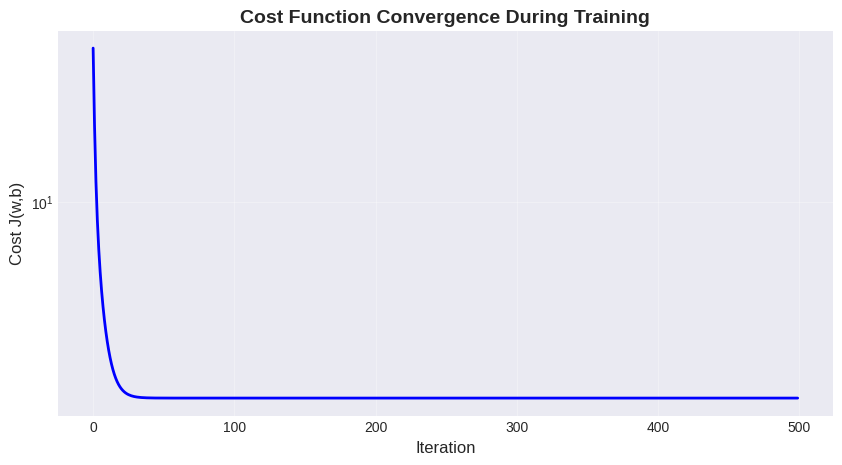

In [20]:
import numpy as np
import matplotlib.pyplot as plt

class MultipleLinearRegression:
    """
    Multiple Linear Regression with Vectorized Implementation
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Fit the model using gradient descent

        Args:
            X: numpy array of shape (m, n) - training features
            y: numpy array of shape (m,) - target values
        """
        m, n = X.shape

        # Initialize parameters
        self.w = np.zeros(n)
        self.b = 0
        self.cost_history = []

        for i in range(self.n_iterations):
            # Vectorized prediction: f = X @ w + b
            y_pred = np.dot(X, self.w) + self.b

            # Calculate cost (MSE)
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

            # Calculate gradients (vectorized)
            error = y_pred - y
            dw = (1/m) * np.dot(X.T, error)
            db = (1/m) * np.sum(error)

            # Update parameters
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Optional: print progress
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

    def predict(self, X):
        """Make predictions for new data"""
        return np.dot(X, self.w) + self.b

    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

# Generate sample dataset with multiple features
np.random.seed(42)
m = 100  # number of examples
n = 3    # number of features

# Create feature matrix X (m x n)
X = np.random.randn(m, n) * 2

# True parameters
true_w = np.array([2.5, -1.8, 3.2])
true_b = 4.1

# Generate target with some noise
y = np.dot(X, true_w) + true_b + np.random.randn(m) * 2

# Split into train/test
split = int(0.8 * m)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training set: {X_train.shape[0]} examples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} examples, {X_test.shape[1]} features")
print(f"True parameters: w = {true_w}, b = {true_b}")

# Train model
model = MultipleLinearRegression(learning_rate=0.1, n_iterations=500)
model.fit(X_train, y_train)

print(f"\nLearned parameters:")
print(f"  w = {model.w}")
print(f"  b = {model.b:.4f}")

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\nR² Score - Train: {train_score:.4f}, Test: {test_score:.4f}")

# Plot cost history
plt.figure(figsize=(10, 5))
plt.plot(model.cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(w,b)', fontsize=12)
plt.title('Cost Function Convergence During Training', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()


**Code Explanation:** This implementation demonstrates the power of vectorization. Notice how:
- `np.dot(X, self.w)` computes predictions for all examples in one operation
- `np.dot(X.T, error)` computes all gradients simultaneously
- No explicit loops over features or examples in the core computations
- The code scales seamlessly to any number of features

### 6.2 Feature Scaling and Comparison

Training on unscaled data (with very small learning rate):
Iteration 0: Cost = 70792.432010
Iteration 50: Cost = 56041727439707197799817933011974686619152668708115866201771943539989289358934621567719361740800.000000
Iteration 100: Cost = 45163153787997772502878939693686928470516062040747739181405218375645594112023626780893183757903982874811963480557456771959558919788272739562391370532646086797146904217109401043455705088.000000
Iteration 150: Cost = 36396281008161034157743065333626102484878771478531836375567734768840273939386424607196129586152950284469457869682741858841405180305285476502196550824392615605216450120509442065436947810253780495775779227173637956632201710665417479126804383868092465763879473299387949799964672.000000

Training on scaled data (with normal learning rate):
Iteration 0: Cost = 70792.432010
Iteration 50: Cost = 26018.377097
Iteration 100: Cost = 9649.685653
Iteration 150: Cost = 3662.180706

Unscaled model - First 5 costs: [np.float64(70792.43201028215), np.float64

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_431/2693712763.py:37: RuntimeWarning: overflow encountered in square
  cost = (1/(2*m)) * np.sum((y_pred - y)**2)


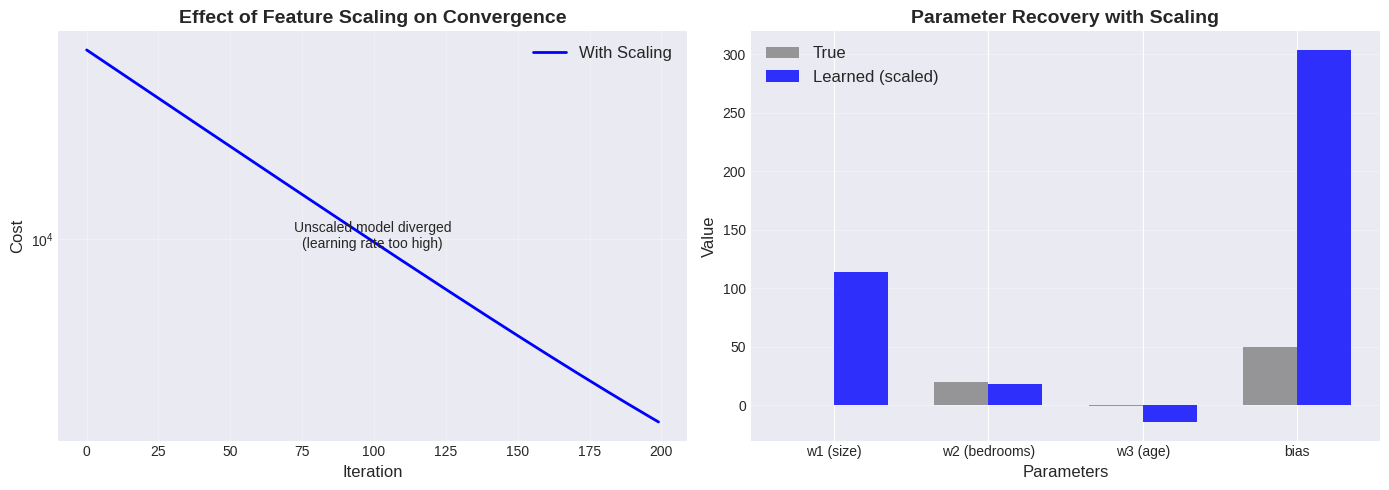


Why the unscaled model struggles:
Feature scales: Size (~1324), Bedrooms (~1.17), Age (~30.3)
This means gradients for 'size' are ~1132x larger than for 'bedrooms'!


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class MultipleLinearRegression:
    """
    Multiple Linear Regression with Vectorized Implementation
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Fit the model using gradient descent

        Args:
            X: numpy array of shape (m, n) - training features
            y: numpy array of shape (m,) - target values
        """
        m, n = X.shape

        # Initialize parameters
        self.w = np.zeros(n)
        self.b = 0
        self.cost_history = []

        for i in range(self.n_iterations):
            # Vectorized prediction: f = X @ w + b
            y_pred = np.dot(X, self.w) + self.b

            # FIXED: Use (1/(2*m)) NOT (1/(2**m))
            # (2**m) would be 2^200 which is enormous and causes overflow
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

            # Calculate gradients (vectorized)
            error = y_pred - y
            dw = (1/m) * np.dot(X.T, error)
            db = (1/m) * np.sum(error)

            # Update parameters
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Optional: print progress
            if i % 50 == 0:
                print(f"Iteration {i}: Cost = {cost:.6f}")

    def predict(self, X):
        """Make predictions for new data"""
        return np.dot(X, self.w) + self.b

    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

# Generate data with features on different scales
np.random.seed(42)
m = 200
n = 3

# Features with very different scales
X = np.column_stack([
    np.random.uniform(500, 5000, m),      # house size (500-5000 sq ft)
    np.random.uniform(1, 5, m),           # bedrooms (1-5)
    np.random.uniform(1, 100, m)          # house age (1-100 years)
])

true_w = np.array([0.1, 20, -0.5])  # weights
true_b = 50
y = np.dot(X, true_w) + true_b + np.random.randn(m) * 20

# Create two versions: original and scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train on original (unscaled) data - use a VERY small learning rate
print("Training on unscaled data (with very small learning rate):")
model_unscaled = MultipleLinearRegression(learning_rate=0.000001, n_iterations=200)
model_unscaled.fit(X, y)

print("\nTraining on scaled data (with normal learning rate):")
model_scaled = MultipleLinearRegression(learning_rate=0.01, n_iterations=200)
model_scaled.fit(X_scaled, y)

# Check if we have valid cost histories
print(f"\nUnscaled model - First 5 costs: {model_unscaled.cost_history[:5]}")
print(f"Scaled model - First 5 costs: {model_scaled.cost_history[:5]}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost convergence comparison
if all(np.isfinite(model_unscaled.cost_history)):  # Check if all values are finite
    axes[0].plot(model_unscaled.cost_history, 'r-', linewidth=2, label='Without Scaling')
else:
    print("Warning: Unscaled model produced non-finite values")
    axes[0].text(0.5, 0.5, 'Unscaled model diverged\n(learning rate too high)',
                 ha='center', va='center', transform=axes[0].transAxes)

if all(np.isfinite(model_scaled.cost_history)):
    axes[0].plot(model_scaled.cost_history, 'b-', linewidth=2, label='With Scaling')
else:
    print("Warning: Scaled model produced non-finite values")

axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost', fontsize=12)
axes[0].set_title('Effect of Feature Scaling on Convergence', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Parameter comparison
features = ['w1 (size)', 'w2 (bedrooms)', 'w3 (age)', 'bias']
x_pos = np.arange(len(features))
width = 0.35

# Prepare data for bar plot
true_values = [true_w[0], true_w[1], true_w[2], true_b]
scaled_values = [model_scaled.w[0], model_scaled.w[1], model_scaled.w[2], model_scaled.b]

axes[1].bar(x_pos - width/2, true_values, width, label='True', alpha=0.8, color='gray')
axes[1].bar(x_pos + width/2, scaled_values, width, label='Learned (scaled)', alpha=0.8, color='blue')
axes[1].set_xlabel('Parameters', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Parameter Recovery with Scaling', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(features)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nWhy the unscaled model struggles:")
print(f"Feature scales: Size (~{X[:,0].std():.0f}), Bedrooms (~{X[:,1].std():.2f}), Age (~{X[:,2].std():.1f})")
print(f"This means gradients for 'size' are ~{X[:,0].std()/X[:,1].std():.0f}x larger than for 'bedrooms'!")


**Code Explanation:** This example shows why feature scaling is crucial. Features with vastly different scales (house size 500-5000 vs bedrooms 1-5) cause the cost surface to be elongated, making gradient descent oscillate and converge slowly. Scaling (standardization: subtract mean, divide by standard deviation) makes all features comparable, leading to faster, more stable convergence.

## 7. Key Takeaways

1. **Multiple features dramatically improve predictions** – Real-world problems are rarely explained by a single variable. Adding relevant features captures more complexity and improves model accuracy.

2. **Vectorization is non-negotiable for modern ML** – Using `np.dot()` and array operations instead of loops can speed up computations by 100-500x, making large-scale learning feasible.

3. **Gradient descent scales gracefully** – The algorithm updates all parameters simultaneously with the same computational pattern, whether you have 3 features or 3,000.

4. **Feature scaling is essential** – When features have different units or scales, gradient descent becomes inefficient. Standardizing features (mean=0, variance=1) ensures stable and fast convergence.

5. **The dot product is your friend** – The expression $\vec{w} \cdot \vec{x} + b$ is both mathematically elegant and computationally efficient, representing the core of linear prediction.

6. **Cost function visualization reveals learning dynamics** – Monitoring cost during training (especially on a log scale) shows whether your model is learning properly and when it has converged.

7. **Normal equation is a niche alternative** – While it provides a closed-form solution for linear regression, its limitations (no generalization, poor scaling) make gradient descent the preferred approach.

## 8. Quick Revision

### Key Formulas

| Component | Mathematical Expression | Vectorized Code |
|-----------|------------------------|-----------------|
| Model Prediction | $f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$ | `np.dot(w, x) + b` |
| Cost Function (MSE) | $J(\vec{w},b) = \frac{1}{2m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})^2$ | `(1/(2*m)) * np.sum((y_pred - y)**2)` |
| Gradient w.r.t w_j | $\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$ | `(1/m) * np.dot(X.T, error)` |
| Gradient w.r.t b | $\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^m (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$ | `(1/m) * np.sum(error)` |
| Parameter Update | $w_j = w_j - \alpha \frac{\partial J}{\partial w_j}$ | `w -= alpha * dw` |

### Key Definitions

- **Multiple Linear Regression**: Linear model with $n \geq 2$ input features
- **Feature Vector ($\vec{x}$)**: Collection of all input variables for one example
- **Weight Vector ($\vec{w}$)**: Collection of all feature coefficients
- **Dot Product**: $\vec{w} \cdot \vec{x} = \sum_{j=1}^n w_j x_j$
- **Vectorization**: Using array operations to avoid explicit loops
- **Feature Scaling**: Transforming features to similar scales (e.g., standardization)
- **Gradient Descent**: Iterative optimization using parameter gradients
- **Normal Equation**: Closed-form solution: $\vec{w} = (X^T X)^{-1} X^T \vec{y}$

### Common Pitfalls to Avoid

1. **Not vectorizing** – Writing explicit loops when array operations exist
2. **Ignoring feature scales** – Letting features with large values dominate gradients
3. **Updating parameters sequentially** – Must update all $w_j$ and $b$ simultaneously
4. **Using normal equation for n > 10,000** – Matrix inversion becomes too expensive
5. **Forgetting the bias term** – The model needs $b$ to shift predictions vertically

### Memory Aid: "VECTOR"
- **V**ectorize all operations
- **E**nsure features are scaled
- **C**ost function monitors progress
- **T**une learning rate carefully
- **O**ptimize all parameters jointly
- **R**epeat until convergence